In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import croak
from croak.maths import wlfreq

def center(t, intensity):
    """Peak-centre and peak-normalise (retrieval is defined up to a time shift)."""
    i = int(np.argmax(intensity))
    return t - t[i], intensity / intensity.max()

def fwhm_fs(t, intensity):
    tc, ic = center(t, intensity)
    return croak.maths.fwhm(tc, ic) * 1e15

g = croak.Grid(256, dt=0.15e-15)
omega0 = wlfreq(260e-9)                        # 260 nm carrier
ew = croak.gaussian_pulse(g, 1.5e-15)          # transform-limited, 1.5 fs
delays = np.linspace(-18e-15, 18e-15, 90)

I_true = np.abs(g.ifft(ew)) ** 2
print(f"true temporal FWHM = {fwhm_fs(g.t, I_true):.2f} fs")

true temporal FWHM = 1.50 fs


In [2]:
disp = dict(material="SiO2", thickness=50e-6, npoints=20, omega0=omega0)
print(f"GDD of the slab at 260 nm = "
      f"{croak.dispersion.material_gdd('SiO2', omega0, disp['thickness']):.1f} fs²")

trace = croak.maketrace(g.omega, delays, ew, "pg", **disp)
trace.shape

GDD of the slab at 260 nm = 10.4 fs²


(256, 90)

In [3]:
near = croak.gaussian_pulse(g, 2.0e-15)
res = croak.retrieve(trace, g.omega, delays, "pg", algorithm="copra",
                    guess=near, maxiters=300, rng=np.random.default_rng(0), **disp)
print(f"trace error R  = {res.error:.2e}")
print(f"recovered FWHM = {fwhm_fs(res.t, res.intensity_t):.2f} fs"
      f"   (true {fwhm_fs(g.t, I_true):.2f} fs)")

retrieving:   0%|          | 0/300 [00:00<?, ?it/s]

retrieval complete — copra / pg
  final error R    : 0.0000%
  retrieved FWHM   : 1.50 fs
  transform limit  : 1.50 fs
  iterations       : 300
  time taken       : 7.73 s
trace error R  = 2.37e-16
recovered FWHM = 1.50 fs   (true 1.50 fs)


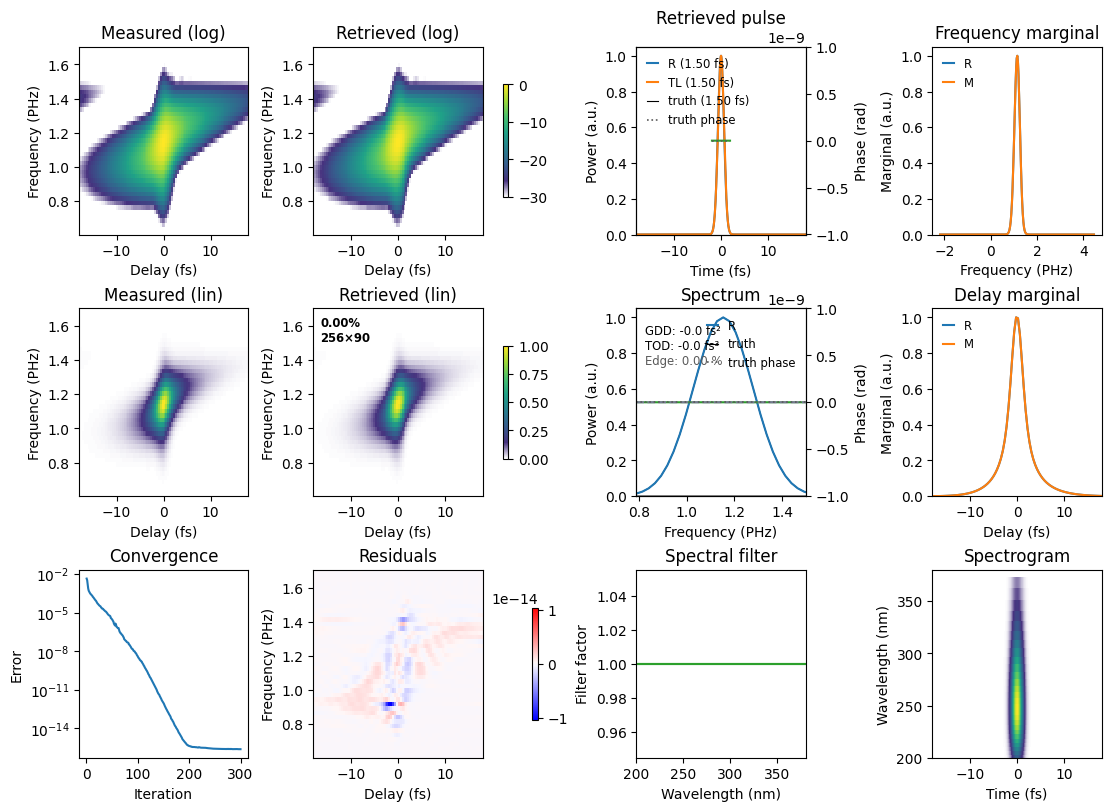

In [4]:
truth = croak.TruthPulse.from_spectrum(g, ew, omega0)
f0 = omega0 / (2 * np.pi)          # PG is degenerate: signal at the fundamental

fig = croak.plot_retrieval(res, measured=trace, truth=truth,
                           lam_min=200e-9, lam_max=380e-9,
                           flim=(f0 - 0.55e15, f0 + 0.55e15))
fig.set_size_inches(11, 8)
fig                                # return the Figure so the notebook displays it

In [5]:
res_thin = croak.retrieve(trace, g.omega, delays, "pg", algorithm="copra",
                         guess=near, maxiters=300, rng=np.random.default_rng(0))
print(f"thin-model trace error R = {res_thin.error:.2e}")
print(f"thin-model FWHM          = {fwhm_fs(res_thin.t, res_thin.intensity_t):.2f} fs"
      f"   (true {fwhm_fs(g.t, I_true):.2f} fs)")

retrieving:   0%|          | 0/300 [00:00<?, ?it/s]

retrieval complete — copra / pg
  final error R    : 0.3365%
  retrieved FWHM   : 3.09 fs
  transform limit  : 0.84 fs
  iterations       : 300
  time taken       : 2.78 s
thin-model trace error R = 3.36e-03
thin-model FWHM          = 3.07 fs   (true 1.50 fs)


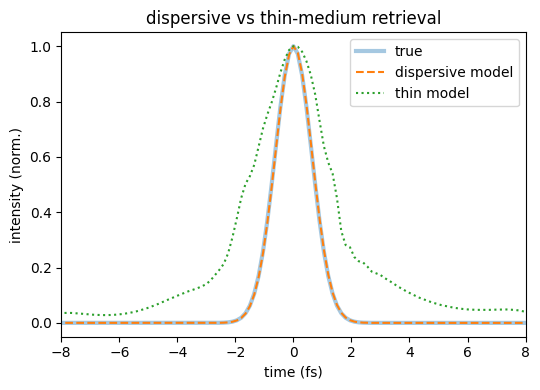

In [6]:
t_true, I_true_n = center(g.t, I_true)
t_disp, I_disp_n = center(res.t, res.intensity_t)
t_thin, I_thin_n = center(res_thin.t, res_thin.intensity_t)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(t_true * 1e15, I_true_n, lw=3, alpha=0.4, label="true")
ax.plot(t_disp * 1e15, I_disp_n, "--", lw=1.5, label="dispersive model")
ax.plot(t_thin * 1e15, I_thin_n, ":", lw=1.5, label="thin model")
ax.set_xlim(-8, 8)
ax.set_xlabel("time (fs)")
ax.set_ylabel("intensity (norm.)")
ax.legend()
ax.set_title("dispersive vs thin-medium retrieval")
fig.tight_layout()

In [7]:
print(f"dispersive model:  R = {res.error:.1e}   FWHM = {fwhm_fs(res.t, res.intensity_t):.2f} fs")
print(f"thin model:        R = {res_thin.error:.1e}   FWHM = {fwhm_fs(res_thin.t, res_thin.intensity_t):.2f} fs")
print(f"truth:                              FWHM = {fwhm_fs(g.t, I_true):.2f} fs")

dispersive model:  R = 2.4e-16   FWHM = 1.50 fs
thin model:        R = 3.4e-03   FWHM = 3.07 fs
truth:                              FWHM = 1.50 fs
